/home/ton618wsl/qwhether_forecasting/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


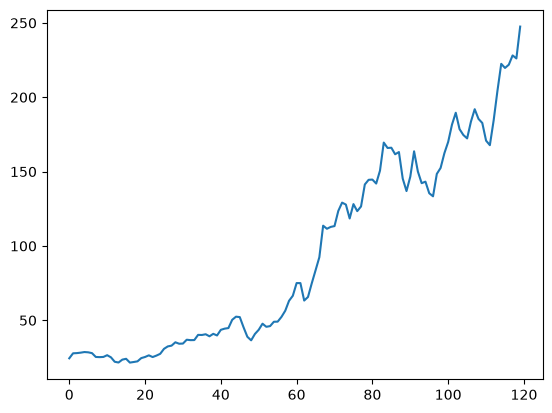

In [1]:
import numpy as np
import matplotlib.pyplot as plt

from models.timefm import TimesFMModel
from models.lstm import LSTMModel, QLSTMModel
from models.gan import QGanModel, MultiSequenceGAN
from sklearn.preprocessing import StandardScaler

data = np.load('data/aapl_stock_monthly.npy')
plt.plot(data)

In [ ]:
## Times FM
model = TimesFMModel(data = data, horizon= 6, historical_lookup= 6)
contexts, predictions, actuals = model.backtest()
results = model.metrics(
    predictions,
    actuals
)
results

In [ ]:
## LSTM 

lstm = LSTMModel(
    data=data,
    horizon=6,
    historical_lookup=6,
    hidden_size=64,
    num_layers=2,
    dropout=0.1,
    epochs=1000,
    batch_size=32,
    learning_rate=1e-3,
    train_ratio=0.8
)

history = lstm.train()
contexts, predictions, actuals = lstm.backtest()
results = lstm.metrics(
    predictions,
    actuals
)
results

In [ ]:
qlstm = QLSTMModel(
    data=data,
    horizon=6,
    historical_lookup=6,

    hidden_size=16,
    n_qubits=4,
    quantum_layers=4,

    epochs=100,
    batch_size=8,
    learning_rate=1e-3,

    train_ratio=0.8
)

history = qlstm.train()
contexts, predictions, actuals = qlstm.backtest()   
results = qlstm.metrics(
    predictions,
    actuals
)
results

In [ ]:
## GAN - Single Sequence QC
qgan = QGanModel(
    data=data,
    type="QC",
    horizon=6,
    historical_lookup=6,
    latent_size=4,
    hidden_size=32,
    epochs=50,
    batch_size=32,
    learning_rate=1e-3
)
history = qgan.train()
contexts, predictions, actuals = qgan.backtest()   
results = qgan.metrics(predictions, actuals)
results

In [ ]:
## GAN - Single Sequence CC
qgan = QGanModel(
    data=data,
    type="CC",
    horizon=6,
    historical_lookup=6,
    latent_size=4,
    hidden_size=32,
    epochs=50,
    batch_size=32,
    learning_rate=1e-3
)
history = qgan.train()
contexts, predictions, actuals = qgan.backtest()   
results = qgan.metrics(predictions, actuals)
results

In [ ]:
## GAN - Multi Sequence QC
msgan_qc = MultiSequenceGAN(
    data=data,
    type="QC",
    historical_lookup=6,
    horizon=6,
    lag=2,
    latent_size=8,
    n_qubits=6,
    quantum_layers=4,
    hidden_size=32,
    epochs=500,
    batch_size=32,
    learning_rate=1e-4,
    diversity_loss_weight= 0.1,
    variety_loss_weight= 0.5,
    train_ratio=0.8,   # be explicit if you plan to compare CC/QC/CQ/QQ side by side
    seed=42,            # pin explicitly so this run is reproducible/comparable across architectures
)
history = msgan_qc.train()
d = msgan_qc.backtest(return_all_sequences=True)
contexts = d['contexts'] 
predictions = d['predictions']
actuals = d['actuals']    
all_seq = d['all_sequences']
prob_result = msgan_qc.probabilistic_metrics(all_seq, actuals)
results = msgan_qc.metrics(predictions, actuals)
results


Training Model C MultiSequenceGAN type=QC
Generator: Quantum
Discriminator: Classical
Trend: causal local linear (trend-aware residual GAN)
Selector: jointly trained neural trajectory selector
[QC] Epoch 1/500 G=2.5863 D=0.6978 Variety=3.2689 Diversity=-0.1386 Selector=1.6060
[QC] Epoch 10/500 G=2.4486 D=0.6897 Variety=3.1127 Diversity=-0.1774 Selector=1.4851
[QC] Epoch 20/500 G=2.3442 D=0.6789 Variety=3.1491 Diversity=-0.2292 Selector=1.1477
[QC] Epoch 30/500 G=2.3636 D=0.6624 Variety=3.3281 Diversity=-0.2841 Selector=1.0174
[QC] Epoch 40/500 G=2.1136 D=0.6430 Variety=2.8847 Diversity=-0.3280 Selector=0.9578
[QC] Epoch 50/500 G=2.2775 D=0.6154 Variety=3.2236 Diversity=-0.3937 Selector=1.0424
[QC] Epoch 60/500 G=2.1557 D=0.5837 Variety=3.0445 Diversity=-0.4640 Selector=0.9536
[QC] Epoch 70/500 G=2.1973 D=0.5564 Variety=3.1776 Diversity=-0.5490 Selector=0.9729
[QC] Epoch 80/500 G=2.0805 D=0.5469 Variety=2.9037 Diversity=-0.5851 Selector=0.9568
[QC] Epoch 90/500 G=2.0248 D=0.5241 Variet

{'overall': {'MAE': 21.352468490600586,
  'RMSE': 27.50108528137207,
  'MAPE': 11.48481559753418,
  'MAPE_excluded_fraction': 0.0,
  'R2': -0.2581239938735962},
 'per_horizon': {'Day +1': {'MAE': 16.72392463684082,
   'RMSE': 21.66864776611328,
   'MAPE': 9.676809310913086,
   'MAPE_excluded_fraction': 0.0,
   'R2': 0.026770293712615967},
  'Day +2': {'MAE': 19.176647186279297,
   'RMSE': 24.271617889404297,
   'MAPE': 10.810869216918945,
   'MAPE_excluded_fraction': 0.0,
   'R2': -0.10069918632507324},
  'Day +3': {'MAE': 19.273479461669922,
   'RMSE': 26.14646339416504,
   'MAPE': 10.476551055908203,
   'MAPE_excluded_fraction': 0.0,
   'R2': -0.18927109241485596},
  'Day +4': {'MAE': 20.222265243530273,
   'RMSE': 27.751144409179688,
   'MAPE': 10.575242042541504,
   'MAPE_excluded_fraction': 0.0,
   'R2': -0.32278621196746826},
  'Day +5': {'MAE': 24.003612518310547,
   'RMSE': 28.902101516723633,
   'MAPE': 12.568346977233887,
   'MAPE_excluded_fraction': 0.0,
   'R2': -0.55621325

In [3]:
prob_result

{'overall_CRPS': 23.136536753712573,
 'per_horizon_CRPS': {'Day +1': 16.677319402142988,
  'Day +2': 19.127203139978555,
  'Day +3': 20.438827943092534,
  'Day +4': 22.160577724936687,
  'Day +5': 27.050137313128175,
  'Day +6': 33.36515499899648}}

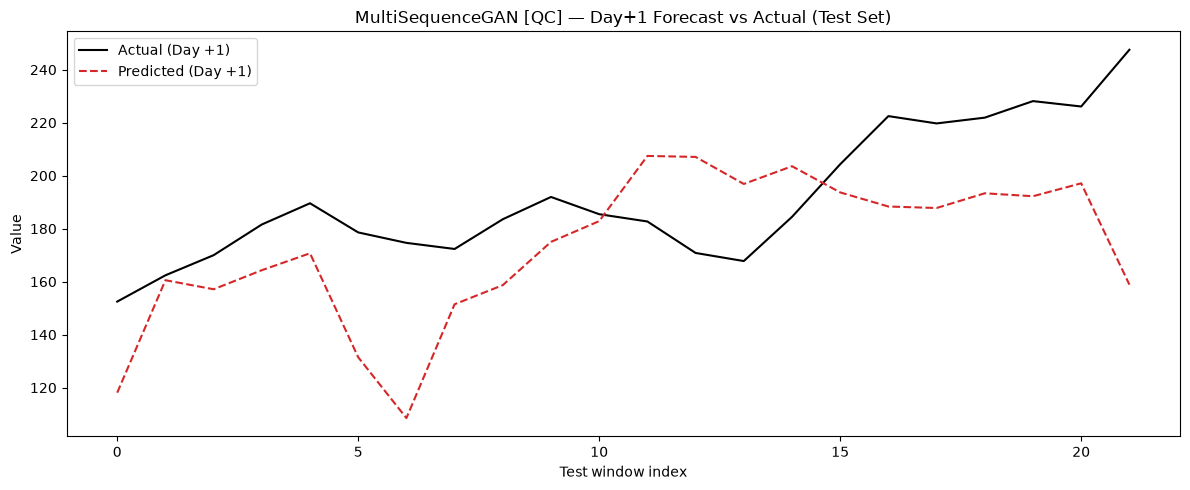

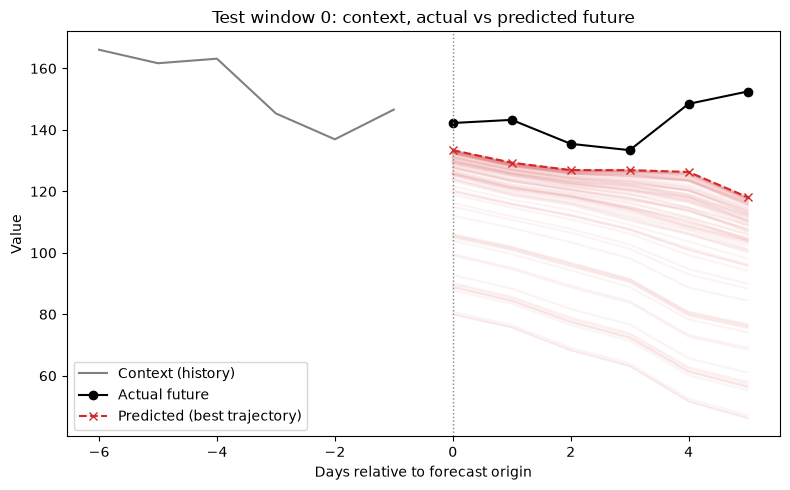

In [4]:
import matplotlib.pyplot as plt
import numpy as np

# 1) Day+1-ahead forecast vs actual, across the whole chronological test set
day1_actual = actuals[:, 5]
day1_pred = predictions[:, 5]

plt.figure(figsize=(12, 5))
plt.plot(day1_actual, label="Actual (Day +1)", color="black")
plt.plot(day1_pred, label="Predicted (Day +1)", color="tab:red", linestyle="--")
plt.title(f"MultiSequenceGAN [{msgan_qc.type}] — Day+1 Forecast vs Actual (Test Set)")
plt.xlabel("Test window index")
plt.ylabel("Value")
plt.legend()
plt.tight_layout()
plt.show()

# 2) Full 6-day window for one test example: context, actual future, predicted
#    future, and the full generated ensemble spread
idx = 0  # change to inspect a different test window
ensemble = all_seq[idx]  # shape: (horizon, n_sequences)

x_context = np.arange(-msgan_qc.historical_lookup, 0)
x_future = np.arange(0, msgan_qc.horizon)

plt.figure(figsize=(8, 5))
plt.plot(x_context, contexts[idx], label="Context (history)", color="gray")
plt.plot(x_future, actuals[idx], label="Actual future", color="black", marker="o")
plt.plot(x_future, predictions[idx], label="Predicted (best trajectory)", color="tab:red", linestyle="--", marker="x")
for s in range(ensemble.shape[1]):
    plt.plot(x_future, ensemble[:, s], color="tab:red", alpha=0.05)  # faint ensemble spread
plt.axvline(0, color="gray", linestyle=":", linewidth=1)
plt.title(f"Test window {idx}: context, actual vs predicted future")
plt.xlabel("Days relative to forecast origin")
plt.ylabel("Value")
plt.legend()
plt.tight_layout()
plt.show()